<a href="https://colab.research.google.com/github/tciodaro/GRLCDDR1C1-N2-L2-PB/blob/main/processamento_texto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn import datasets



datasets.fetch_20newsgroups?

In [56]:
trn = datasets.fetch_20newsgroups(subset='train')

data = trn.data[:100]
target = trn.target[:100]
target_names = trn.target_names

# trn

In [10]:
print(f"Number of training samples: {len(trn.data)}")
print(f"Number of training labels: {len(trn.target)}")
print(f"Categories (target names): {trn.target_names}")
print(f"First document's category name: {trn.target_names[trn.target[0]]}")

Number of training samples: 11314
Number of training labels: 11314
Categories (target names): ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']
First document's category name: rec.autos


# Count Vectorizer

In [54]:
import nltk

fSTEM = False
fLEMMA = True


In [57]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize


if fSTEM:
  # Initialize PorterStemmer
  stemmer = PorterStemmer()

  def stem_text(text):
      tokens = word_tokenize(text)
      stemmed_tokens = [stemmer.stem(token) for token in tokens]
      return " ".join(stemmed_tokens)

  print("PorterStemmer and stem_text function defined.")

  normed_data = [stem_text(doc) for doc in data]

if fLEMMA:
  import spacy
  # Load the spaCy language model
  nlp = spacy.load('en_core_web_sm')

  def lemmatize_corpus(corpus):
      lemmatized_texts = []
      for doc_text in corpus:
          # Process the document with the loaded nlp model
          doc = nlp(doc_text)
          # Extract lemmas, convert to lowercase, and filter for alphabetic tokens
          lemmas = [token.lemma_.lower() for token in doc if token.is_alpha and not token.is_space]
          # Join the lemmas back into a single string
          lemmatized_texts.append(' '.join(lemmas))
      return lemmatized_texts

  normed_data = lemmatize_corpus(data)


  if not fLEMMA and not fSTEM:
    normed_data = data


  # print("First 5 lemmatized documents:")
  # for i, doc in enumerate(lemmatized_data[:5]):
  #     print(f"Document {i+1}: {doc}\n")



vectorizer = CountVectorizer(
    token_pattern=r"(?u)\b[A-Za-z]+\b",
    max_df=0.975,
    min_df=0.025
)
trn_vec = vectorizer.fit_transform(normed_data)

# Print the learned vocabulary
print("Vocabulary:", X.shape[1])


# trn.data



Vocabulary: 950


In [65]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors = 10)

knn = knn.fit(trn_vec, target)

prediction = knn.predict(trn_vec)


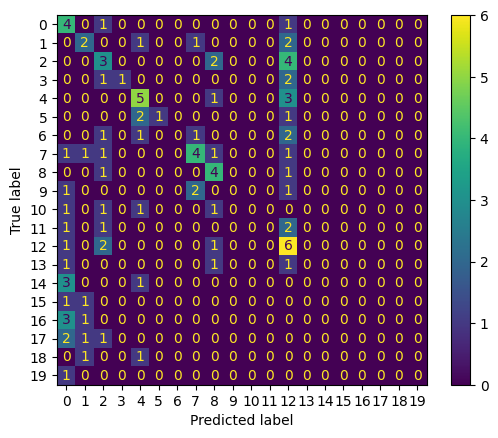

In [66]:
from sklearn import metrics

metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(target, prediction)).plot()

In [68]:
print(metrics.classification_report(target, prediction, target_names=target_names))

                          precision    recall  f1-score   support

             alt.atheism       0.20      0.67      0.31         6
           comp.graphics       0.29      0.33      0.31         6
 comp.os.ms-windows.misc       0.23      0.33      0.27         9
comp.sys.ibm.pc.hardware       1.00      0.25      0.40         4
   comp.sys.mac.hardware       0.42      0.56      0.48         9
          comp.windows.x       1.00      0.25      0.40         4
            misc.forsale       0.00      0.00      0.00         5
               rec.autos       0.50      0.44      0.47         9
         rec.motorcycles       0.36      0.67      0.47         6
      rec.sport.baseball       0.00      0.00      0.00         4
        rec.sport.hockey       0.00      0.00      0.00         4
               sci.crypt       0.00      0.00      0.00         4
         sci.electronics       0.22      0.60      0.32        10
                 sci.med       0.00      0.00      0.00         3
         

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


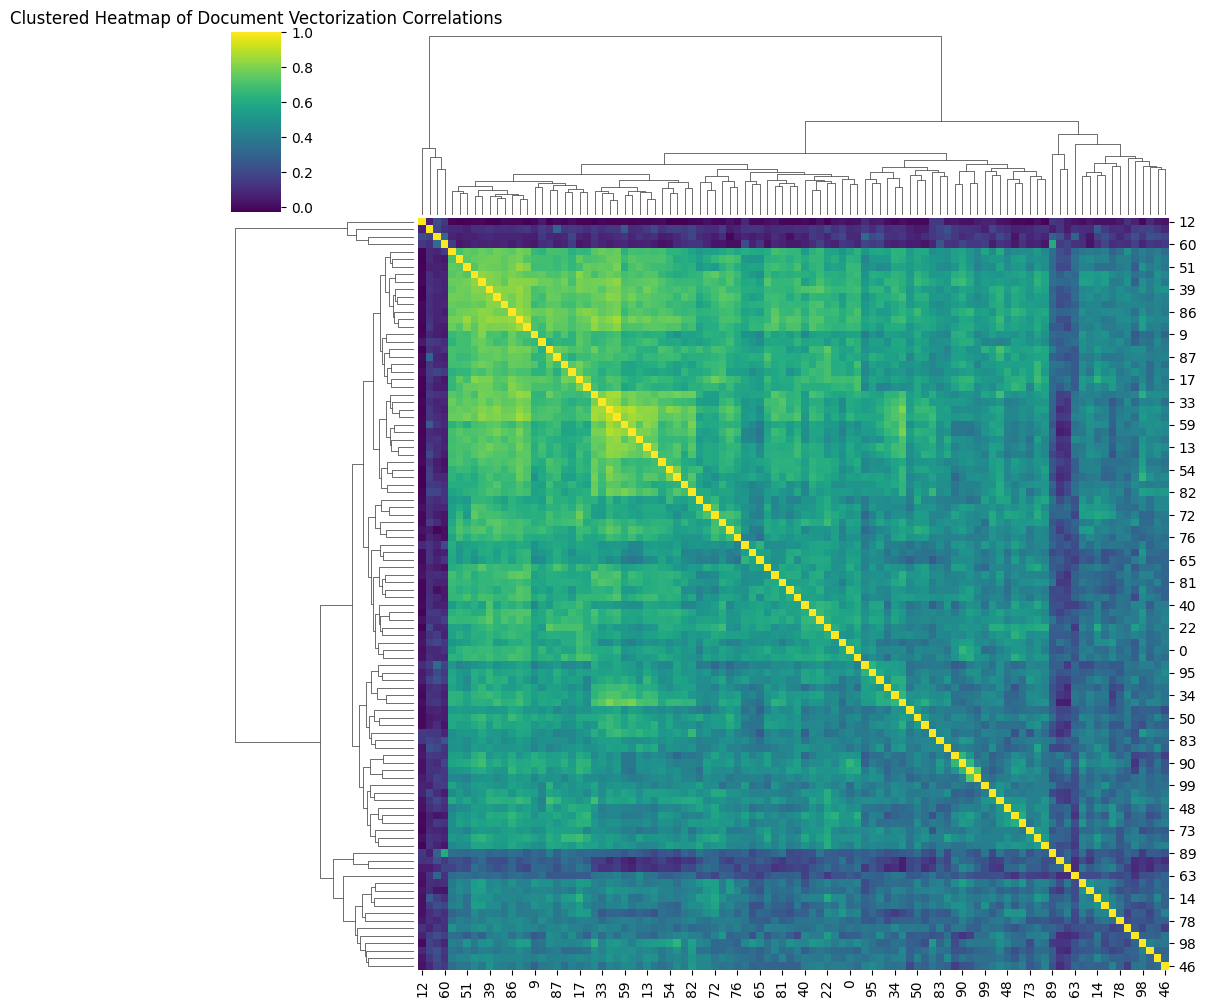

In [91]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn


C = np.corrcoef(trn_vec.toarray())

# Create a clustered heatmap
sns.clustermap(C, cmap='viridis', figsize=(10, 10))
plt.title('Clustered Heatmap of Document Vectorization Correlations')
plt.show()

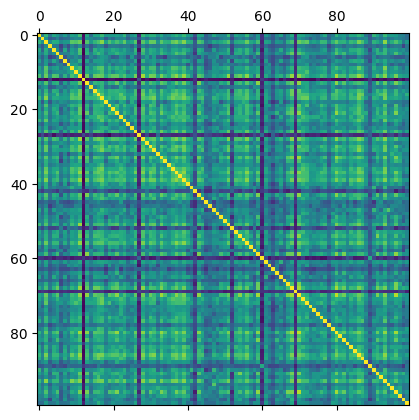

In [82]:
C

array([[1.        , 0.40999666, 0.64792519, ..., 0.43518381, 0.42233305,
        0.33791045],
       [0.40999666, 1.        , 0.49726638, ..., 0.42418269, 0.38242657,
        0.34365399],
       [0.64792519, 0.49726638, 1.        , ..., 0.60498219, 0.39392713,
        0.532135  ],
       ...,
       [0.43518381, 0.42418269, 0.60498219, ..., 1.        , 0.29819257,
        0.4254302 ],
       [0.42233305, 0.38242657, 0.39392713, ..., 0.29819257, 1.        ,
        0.39330636],
       [0.33791045, 0.34365399, 0.532135  , ..., 0.4254302 , 0.39330636,
        1.        ]])

# Mini Exemplo

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

corpus = [
    'This is the 09 first document.',
    'This is the second document',
    'And the third one.',
    'Is this the first document?',
]

# Use token_pattern to exclude digits (only match alphabetic words)
# vectorizer = CountVectorizer(token_pattern=r"(?u)\b[A-Za-z]+\b")
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

# Print the learned vocabulary
print("Vocabulary:", vectorizer.get_feature_names_out())

# Print the numerical count matrix (dense representation for viewing)
print("Count Matrix:\n", X.toarray())

# trn.data

Vocabulary: ['09' 'and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
Count Matrix:
 [[1 0 1 1 1 0 0 1 0 1]
 [0 0 1 0 1 0 1 1 0 1]
 [0 1 0 0 0 1 0 1 1 0]
 [0 0 1 1 1 0 0 1 0 1]]


In [51]:
# import sys
# !{sys.executable} -m pip install spacy
# !{sys.executable} -m spacy download en_core_web_sm

# print("spaCy installed and 'en_core_web_sm' model downloaded.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy installed and 'en_core_web_sm' model downloaded.
